# 5c_SIM_TARGETS — Similarity Prediction on Target Grids

Apply the trained Similarity (kernel regression) model to Antarctic and Greenland target grids.

**Outputs per region:**

| Variable | Description |
|---|---|
| `sim_q50_raw` | Raw weighted-mean prediction |
| `sim_q50_corr` | Spline-corrected mean |
| `sim_std_raw` | Weighted std of reference distribution (raw) |
| `sim_std_corr` | Std after spline correction (propagated offset) |
| `sim_lo_raw/corr` | q_mean ± std lower bound |
| `sim_hi_raw/corr` | q_mean ± std upper bound |
| `sim_N` | Mean N_sim (effective neighbourhood size) |
| `sim_shannon_H` | Normalised Shannon entropy of per-point histogram (scalar attribute) |

**Histogram:** Per-point weighted PDF stored as 3D variable `sim_hist` (y, x, bin).
Bins: `HIST_BIN_WIDTH = 0.010` W/m², range `[Q_CLIP_MIN, q_clip_max]`.

**Batching:** Target points are processed in batches of `BATCH_SIZE = 10000`
to keep the similarity matrix (`batch × n_ref × n_feat`) within memory.

**Files written:**
- `output/targets/Aq15_SIM_v{MODEL_VERSION}.nc` — Antarctica
- `output/targets/Kq15_SIM_v{MODEL_VERSION}.nc` — Greenland

> Requires: `output/models/sim_artefacts.pkl` (written by `4c_SIM_MODEL`)

## 1. Imports & constants

In [1]:
import sys, json, pickle, warnings, datetime, time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from pathlib import Path
from scipy.stats import entropy as scipy_entropy
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
from config import *
sys.path.insert(0, 'lib')
from similarity import similarity_predict

from lib.utils import grid_from_xr_dataset

targets_dir.mkdir(parents=True, exist_ok=True)

# ── Histogram parameters (must match similarity.py constants) ─────────────────
HIST_BIN_WIDTH = 0.010          # [W/m²]
HIST_MAX_BINS  = 400
BATCH_SIZE     = 10_000         # target points per batch

n_bins = int(min((q_clip_max - q_clip_min) / HIST_BIN_WIDTH, HIST_MAX_BINS))
bin_edges = np.linspace(q_clip_min, q_clip_max, n_bins + 1)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

print(f'model version : {MODEL_VERSION}')
print(f'targets_dir   : {targets_dir}')
print(f'hist n_bins   : {n_bins}  bin_width={HIST_BIN_WIDTH} W/m²')
print(f'batch size    : {BATCH_SIZE:,} points')

# ── Result-map helper (shared cartography via agrid.Grid.map) ─────────────────
# Every stage-5 result map goes through this so they all get cartopy coastlines,
# a graticule and the correct polar CRS, and each writes two files into
# fig_dir_targets: the map and a separate colour-bar-with-histogram.
FIG_DIR = fig_dir_targets

def save_target_map(grid, var, *, cmap, vmin, vmax, label, cbar_title, units,
                    stem=None, gridlines=(-180, 180, 30), show=True):
    """Draw one grid field through agrid and save map + histogram colour-bar."""
    stem = stem or f"{label}_{var}"
    fig, ax = grid.map(
        var, cmap=cmap, vmin=vmin, vmax=vmax,
        coastlines=True, gridlines=gridlines,
        cbar_title=cbar_title, cbar_units_label=units,
        ext_cbar=True, histogram=True,
        save_fig=str(FIG_DIR / f"{stem}{FIG_EXT}"),
        save_cbar=str(FIG_DIR / f"{stem}_cbar{FIG_EXT}"),
        dpi=FIG_DPI, show=show, return_fig=True)
    return fig, ax


✓ config.py v4.0 | obs_model: 21 | obs_sweep: 22 | obs: 36
model version : 0_4
targets_dir   : output/targets
hist n_bins   : 34  bin_width=0.01 W/m²
batch size    : 10,000 points


## 2. Helpers

In [2]:
def load_grid(grid_cfg, obs_sel):
    """Load target parquet, validate features, report grid shape."""
    label = grid_cfg['label']
    df    = pd.read_parquet(grid_cfg['parquet'])
    print(f'\n[{label.upper()}] {len(df):,} rows')
    missing = [f for f in obs_sel if f not in df.columns]
    if missing:
        warnings.warn(f'Missing features {missing} — filling NaN')
        for f in missing:
            df[f] = np.nan
    nan_cols = {f: int(df[f].isna().sum()) for f in obs_sel if df[f].isna().any()}
    if nan_cols:
        print(f'  NaN counts: {nan_cols}')
    else:
        print(f'  All {len(obs_sel)} features OK, no NaNs')
    xcol, ycol = grid_cfg['x_col'], grid_cfg['y_col']
    x_vals = np.sort(df[xcol].unique()).astype(np.float64)
    y_vals = np.sort(df[ycol].unique()).astype(np.float64)
    nx, ny = len(x_vals), len(y_vals)
    is_reg = (len(df) == nx * ny)
    if is_reg:
        dx = np.diff(x_vals)
        dy = np.diff(y_vals)
        print(f'  Regular {ny}x{nx}  dx={dx[0]:.0f}m  dy={dy[0]:.0f}m')
    else:
        print(f'  Irregular {len(df):,} pts (expected {ny*nx:,})')
    return df, x_vals, y_vals, ny, nx, is_reg


def build_X(df, obs_sel, scaler):
    """Scale features; return (X_sc, finite_mask)."""
    X_raw  = df[obs_sel].values.astype(np.float32)
    finite = np.isfinite(X_raw).all(axis=1)
    X_sc   = np.full_like(X_raw, np.nan)
    if finite.any():
        X_sc[finite] = scaler.transform(X_raw[finite]).astype(np.float32)
    print(f'  finite points: {finite.sum():,} / {len(df):,}')
    return X_sc, finite


def to_2d(vals_1d, df, x_vals, y_vals, xcol, ycol, is_reg):
    """Reshape flat 1-D array to (ny, nx) grid."""
    from scipy.interpolate import griddata
    ny, nx = len(y_vals), len(x_vals)
    if is_reg:
        tmp = df[[xcol, ycol]].copy()
        tmp['_v'] = vals_1d
        return tmp.pivot(index=ycol, columns=xcol, values='_v').values.astype(np.float32)
    gx, gy = np.meshgrid(x_vals, y_vals)
    return griddata(df[[xcol, ycol]].values, vals_1d,
                    (gx, gy), method='nearest').astype(np.float32)


def apply_spline(spline, vals):
    """Apply PCHIP spline with clipping."""
    out    = np.full(vals.shape, np.nan, dtype=np.float32)
    ok     = np.isfinite(vals)
    out[ok] = np.clip(spline(vals[ok]).astype(np.float32), q_clip_min, q_clip_max)
    return out


def shannon_H_norm(hist_2d, bin_width=HIST_BIN_WIDTH):
    """Normalised Shannon entropy of a 2D field of per-point histograms (n_pts, n_bins).
    Returns a scalar: mean normalised entropy over all finite points."""
    # hist_2d shape: (n_pts, n_bins), each row is a normalised PDF * dq
    # convert to probability mass per bin: p = hist * dq (already done in similarity_predict)
    row_sums = hist_2d.sum(axis=1)                         # should be ~1/dq per row
    valid    = row_sums > 0
    if not valid.any():
        return np.nan
    p = hist_2d[valid] * bin_width                         # probability mass
    p = np.clip(p, 1e-12, None)
    p = p / p.sum(axis=1, keepdims=True)                   # renormalise
    H_arr   = -np.sum(p * np.log(p), axis=1)               # Shannon H per point
    H_max   = np.log(n_bins)
    return float(np.mean(H_arr / H_max)) if H_max > 0 else 0.0


def make_ds(arrays, hist_3d, x_vals, y_vals, bin_centres_arr,
            grid_cfg, params, obs_sel_used, model_tag, extra=None):
    """Build xarray Dataset with all 2D arrays + 3D histogram."""
    coords = {'y': y_vals, 'x': x_vals}
    dvars  = {
        name: xr.DataArray(arr, dims=['y', 'x'], coords=coords,
                           attrs={'units': 'W m-2',
                                  'long_name': name.replace('_', ' ')})
        for name, arr in arrays.items()
    }
    # 3D histogram: (y, x, bin)
    if hist_3d is not None:
        ny, nx = len(y_vals), len(x_vals)
        dvars['sim_hist'] = xr.DataArray(
            hist_3d,
            dims=['y', 'x', 'bin'],
            coords={**coords, 'bin': bin_centres_arr},
            attrs={'units'     : 'W m-2 bin-1',
                   'long_name' : 'weighted similarity PDF per target point',
                   'bin_width' : HIST_BIN_WIDTH}
        )
    ds = xr.Dataset(dvars, coords=coords)
    attrs = dict(
        title        = f'{model_tag} heat-flow prediction',
        model        = model_tag,
        version      = MODEL_VERSION,
        institution  = NETCDF_AUTHOR,
        Conventions  = NETCDF_CONVENTIONS,
        crs          = grid_cfg['crs'],
        epsg         = str(grid_cfg['epsg']),
        region       = grid_cfg['label'].upper(),
        created      = datetime.datetime.utcnow().isoformat() + 'Z',
        obs_sel      = json.dumps(obs_sel_used),
        params_json  = json.dumps(params, default=str),
        hist_bin_width = HIST_BIN_WIDTH,
        hist_n_bins    = n_bins,
        q_clip_min     = float(q_clip_min),
        q_clip_max     = float(q_clip_max),
    )
    if extra:
        attrs.update(extra)
    ds.attrs = attrs
    return ds


def save_nc(ds, path):
    enc = {v: {'zlib': True, 'complevel': netcdf_compression_level, 'dtype': 'float32'}
           for v in ds.data_vars}
    ds.to_netcdf(path, encoding=enc)
    print(f'  Saved {path}  ({path.stat().st_size / 1e6:.1f} MB)')


print('Helpers ready.')

Helpers ready.


## 3. Load Similarity artefacts

In [3]:
with open(model_dir / 'sim_artefacts.pkl', 'rb') as fp:
    art = pickle.load(fp)

obs_sel      = art['obs_sel']          # always from pkl — consistent with scaler
scaler       = art['scaler']
assert scaler.n_features_in_ == len(obs_sel), \
    f'scaler/obs_sel mismatch: scaler={scaler.n_features_in_} obs_sel={len(obs_sel)}'



scaler    = art['scaler']           # StandardScaler fitted on train fold
X_ref     = art['X_tr_ref']         # (n_ref, n_feat) scaled reference features
H_ref     = art['y_tr_ref']         # (n_ref,)  reference heat-flow
W_ref     = art.get('w_tr_ref', np.ones(len(H_ref), dtype=np.float32))
sigma_arr = art['sigma_arr']        # (n_feat,) optimised bandwidths
K         = float(art['K'])
sim_spline= art['spline']           # PCHIP correction spline (canonical key 'spline')
PARAMS    = art['PARAMS']

n_ref, n_feat = X_ref.shape
print(f'Similarity artefacts loaded')
print(f'  n_ref     : {n_ref:,}  n_feat={n_feat}')
print(f'  K         : {K:.4f}')
print(f'  sigma_arr : [{sigma_arr.min():.3f}, {sigma_arr.max():.3f}]')
print(f'  obs_sel   : {obs_sel}')

SIM_KERNEL      = PARAMS.get('SIM_KERNEL', 'rbf')
SIM_WEIGHT_MODE = PARAMS.get('SIM_WEIGHT_MODE', 'shifted_exp')
print(f'  kernel      : {SIM_KERNEL}')
print(f'  weight_mode : {SIM_WEIGHT_MODE}')

Similarity artefacts loaded
  n_ref     : 24,677  n_feat=22
  K         : 11.6787
  sigma_arr : [0.500, 4.278]
  obs_sel   : ['GEOID', 'REVEAL_P150', 'FREE_AIR', 'BOUGUER', 'MOHO', 'LITH_RHO', 'DEM', 'SEDIMENT', 'EMAG2_LOG', 'CRUST_RHO', 'REVEAL_S80', 'REVEAL_VP90VS60', 'REVEAL_S90', 'MAG_SEIS_MOHO', 'CTD', 'SI', 'REVEAL_S100', 'MOHO_GRAV', 'REVEAL_VP50VS80', 'LAB', 'REVEAL_VP60VS70', 'REVEAL_S70']
  kernel      : rbf
  weight_mode : shifted_exp


In [4]:

N_SAMPLE = 20_000

p05_ref = np.percentile(X_ref, 5,  axis=0)
p95_ref = np.percentile(X_ref, 95, axis=0)

all_ood = {}
for grid_cfg in TARGET_GRIDS:
    lbl = grid_cfg['label']
    df_g = pd.read_parquet(grid_cfg['parquet'])
    X_raw = df_g[obs_sel].values.astype(np.float32)
    finite = np.isfinite(X_raw).all(axis=1)
    X_fin  = X_raw[finite]
    rng = np.random.default_rng(42)
    idx = rng.choice(len(X_fin), size=min(N_SAMPLE, len(X_fin)), replace=False)
    X_sc = scaler.transform(X_fin[idx]).astype(np.float32)
    all_ood[lbl] = np.mean((X_sc < p05_ref) | (X_sc > p95_ref), axis=0)
    print(f'[{lbl.upper()}] sampled {len(idx):,} / {finite.sum():,} finite pts')

labels = sorted(all_ood.keys())
hdr = f"{'Feature':28s}  {'sigma':6s}" + \
      "".join(f"  {f'OOD_{l.upper()[:3]}%':>9s}" for l in labels) + "  VERDICT"
print("\n" + hdr)
print("-" * len(hdr))
for i, feat in enumerate(obs_sel):
    sig   = sigma_arr[i]
    worst = max(all_ood[l][i] for l in labels)
    if   worst > 0.20 and sig < 0.60: verdict = '⚠⚠ HIGH RISK'
    elif worst > 0.30:                 verdict = '⚠  OOD > 30%'
    else:                              verdict = 'OK'
    row = f"{feat:28s}  {sig:6.3f}" + \
          "".join(f"  {all_ood[l][i]*100:8.1f}%" for l in labels)
    print(f"{row}  {verdict}")

[ANT] sampled 20,000 / 1,396,066 finite pts
[GRL] sampled 20,000 / 172,360 finite pts

Feature                       sigma    OOD_ANT%   OOD_GRL%  VERDICT
-------------------------------------------------------------------
GEOID                          0.500      26.5%      29.3%  ⚠⚠ HIGH RISK
REVEAL_P150                    0.500       2.4%       7.5%  OK
FREE_AIR                       0.914       8.3%      25.3%  OK
BOUGUER                        0.563      47.6%      25.4%  ⚠⚠ HIGH RISK
MOHO                           0.500       0.0%       1.1%  OK
LITH_RHO                       0.745      21.4%      17.4%  OK
DEM                            1.345      30.7%       1.8%  ⚠  OOD > 30%
SEDIMENT                       0.500       8.6%      21.5%  ⚠⚠ HIGH RISK
EMAG2_LOG                      0.977       5.7%      16.6%  OK
CRUST_RHO                      1.046      11.1%       7.1%  OK
REVEAL_S80                     0.820      34.0%      22.7%  ⚠  OOD > 30%
REVEAL_VP90VS60                0.6

In [5]:
print(f'scaler n_features: {scaler.n_features_in_}')
print(f'obs_sel length   : {len(obs_sel)}')
print(f'match            : {scaler.n_features_in_ == len(obs_sel)}')
print("obs_sel vs sigma_arr alignment:")
for f, s in zip(obs_sel, sigma_arr):
    print(f"  {f:28s}  σ={s:.4f}")

scaler n_features: 22
obs_sel length   : 22
match            : True
obs_sel vs sigma_arr alignment:
  GEOID                         σ=0.5000
  REVEAL_P150                   σ=0.5000
  FREE_AIR                      σ=0.9140
  BOUGUER                       σ=0.5634
  MOHO                          σ=0.5000
  LITH_RHO                      σ=0.7445
  DEM                           σ=1.3449
  SEDIMENT                      σ=0.5000
  EMAG2_LOG                     σ=0.9770
  CRUST_RHO                     σ=1.0464
  REVEAL_S80                    σ=0.8196
  REVEAL_VP90VS60               σ=0.6928
  REVEAL_S90                    σ=1.2137
  MAG_SEIS_MOHO                 σ=1.6235
  CTD                           σ=1.9875
  SI                            σ=0.7392
  REVEAL_S100                   σ=1.5099
  MOHO_GRAV                     σ=4.2776
  REVEAL_VP50VS80               σ=3.5987
  LAB                           σ=1.9775
  REVEAL_VP60VS70               σ=3.5409
  REVEAL_S70                    σ=1.356

## 4. Batched predict & write NetCDF

For each target region:
1. Load parquet, validate features
2. Scale features with train-fold scaler
3. Loop over batches of `BATCH_SIZE` finite points, calling `similarity_predict` with `hist=True`
4. Apply PCHIP spline to `sim_q50_raw` → `sim_q50_corr`; propagate offset to bounds
5. Reshape to 2D and write compressed NetCDF

In [6]:
# Fix 

# SIM_KERNEL      = PARAMS.get('SIM_KERNEL', 'rbf')
# SIM_WEIGHT_MODE = PARAMS.get('SIM_WEIGHT_MODE', 'shifted_exp')
# print(f'Similarity mode: kernel={SIM_KERNEL} | weight_mode={SIM_WEIGHT_MODE}')

In [7]:
results_sim = {}

for grid_cfg in TARGET_GRIDS:
    label    = grid_cfg['label']
    prefix   = 'Aq15' if label == 'ant' else 'Kq15'
    out_path = targets_dir / f'{prefix}_SIM_v{MODEL_VERSION}.nc'
    xcol, ycol = grid_cfg['x_col'], grid_cfg['y_col']

    df, x_vals, y_vals, ny, nx, is_reg = load_grid(grid_cfg, obs_sel)
    X_sc, finite = build_X(df, obs_sel, scaler)

    n_tgt    = len(df)
    n_finite = finite.sum()

    q_raw_1d  = np.full(n_tgt, np.nan, dtype=np.float32)
    std_1d    = np.full(n_tgt, np.nan, dtype=np.float32)
    N_1d      = np.full(n_tgt, np.nan, dtype=np.float32)
    hist_1d   = np.zeros((n_tgt, n_bins), dtype=np.float32)

    finite_idx = np.where(finite)[0]
    X_finite   = X_sc[finite_idx]
    n_batches  = int(np.ceil(n_finite / BATCH_SIZE))
    print(f'\n[{label.upper()}] {n_finite:,} finite pts → {n_batches} batches')

    t0 = time.time()
    for b in range(n_batches):
        i0 = b * BATCH_SIZE
        i1 = min(i0 + BATCH_SIZE, n_finite)
        X_batch   = X_finite[i0:i1]
        W_t_batch = np.ones(len(X_batch), dtype=np.float32)

        q_b, std_b, N_b, hist_b = similarity_predict(
            X_ref=X_ref, H_ref=H_ref, X_tgt=X_batch,
            W_t=W_t_batch, S_r=sigma_arr, K=K, W_r=W_ref,
            hist=True, n_bins=n_bins,
            q_min=float(q_clip_min), q_max=float(q_clip_max),
            use_sigma_helper=False,
            kernel=SIM_KERNEL, weight_mode=SIM_WEIGHT_MODE,
        )

        idx_slice = finite_idx[i0:i1]
        q_raw_1d[idx_slice]  = q_b.astype(np.float32)
        std_1d[idx_slice]    = std_b.astype(np.float32)
        N_1d[idx_slice]      = N_b.astype(np.float32)
        hist_1d[idx_slice]   = hist_b.astype(np.float32)

        elapsed = time.time() - t0
        eta = elapsed / i1 * (n_finite - i1) if i1 > 0 else 0
        print(f'  batch {b+1:3d}/{n_batches}  pts {i1:>7,}/{n_finite:,}  '
              f'elapsed={elapsed/60:.1f}min  ETA={eta/60:.1f}min')

    print(f'  Total wall time: {(time.time()-t0)/60:.1f} min')

    q_raw_1d   = np.clip(q_raw_1d, q_clip_min, q_clip_max)
    q_corr_1d  = apply_spline(sim_spline, q_raw_1d)
    offset_1d  = np.where(np.isfinite(q_corr_1d), q_corr_1d - q_raw_1d, 0.0).astype(np.float32)

    std_corr_1d = std_1d.copy()
    lo_raw_1d   = np.clip(q_raw_1d  - std_1d,      q_clip_min, q_clip_max)
    hi_raw_1d   = np.clip(q_raw_1d  + std_1d,      q_clip_min, q_clip_max)
    lo_corr_1d  = np.clip(q_corr_1d - std_corr_1d, q_clip_min, q_clip_max)
    hi_corr_1d  = np.clip(q_corr_1d + std_corr_1d, q_clip_min, q_clip_max)

    H_mean = shannon_H_norm(hist_1d[finite_idx])
    print(f'  Shannon H (norm, mean): {H_mean:.4f}')

    def r2(v):
        return to_2d(v, df, x_vals, y_vals, xcol, ycol, is_reg)

    arrays = {
        'sim_q50_raw' : r2(q_raw_1d),
        'sim_q50_corr': r2(q_corr_1d),
        'sim_std_raw' : r2(std_1d),
        'sim_std_corr': r2(std_corr_1d),
        'sim_lo_raw'  : r2(lo_raw_1d),
        'sim_hi_raw'  : r2(hi_raw_1d),
        'sim_lo_corr' : r2(lo_corr_1d),
        'sim_hi_corr' : r2(hi_corr_1d),
        'sim_N'       : r2(N_1d),
    }

    if is_reg:
        tmp = df[[xcol, ycol]].copy().reset_index(drop=True)
        tmp['_row'] = tmp[ycol].map({v: i for i, v in enumerate(y_vals)})
        tmp['_col'] = tmp[xcol].map({v: i for i, v in enumerate(x_vals)})
        hist_3d = np.full((ny, nx, n_bins), np.nan, dtype=np.float32)
        hist_3d[tmp['_row'].values, tmp['_col'].values, :] = hist_1d
    else:
        from scipy.interpolate import griddata
        gx, gy = np.meshgrid(x_vals, y_vals)
        hist_3d = np.stack([
            griddata(df[[xcol, ycol]].values, hist_1d[:, b],
                     (gx, gy), method='nearest').astype(np.float32)
            for b in range(n_bins)
        ], axis=-1)

    ds = make_ds(
        arrays=arrays, hist_3d=hist_3d,
        x_vals=x_vals, y_vals=y_vals,
        bin_centres_arr=bin_centres,
        grid_cfg=grid_cfg, params=PARAMS,
        obs_sel_used=obs_sel,
        model_tag=f'{prefix}_SIM',
        extra={'shannon_H_mean': H_mean,
               'spline_applied': 'sim_q50_corr, sim_lo_corr, sim_hi_corr'},
    )

    grid_cfg['agrid'] = grid_from_xr_dataset(ds, name=label)

    # Store ds and path for the save cell — do NOT save here
    results_sim[label] = {'ds': ds, 'out_path': out_path, 'prefix': prefix}
    print(f'  [{label.upper()}] processing complete — awaiting save.')

print('\nAll grids processed.')


[ANT] 1,779,556 rows
  NaN counts: {'DEM': 383490}
  Regular 1334x1334  dx=5000m  dy=5000m
  finite points: 1,396,066 / 1,779,556

[ANT] 1,396,066 finite pts → 140 batches
  batch   1/140  pts  10,000/1,396,066  elapsed=0.2min  ETA=31.0min
  batch   2/140  pts  20,000/1,396,066  elapsed=0.4min  ETA=29.5min
  batch   3/140  pts  30,000/1,396,066  elapsed=0.7min  ETA=30.9min
  batch   4/140  pts  40,000/1,396,066  elapsed=0.9min  ETA=29.9min
  batch   5/140  pts  50,000/1,396,066  elapsed=1.1min  ETA=29.2min
  batch   6/140  pts  60,000/1,396,066  elapsed=1.3min  ETA=28.8min
  batch   7/140  pts  70,000/1,396,066  elapsed=1.5min  ETA=28.2min
  batch   8/140  pts  80,000/1,396,066  elapsed=1.7min  ETA=27.8min
  batch   9/140  pts  90,000/1,396,066  elapsed=1.9min  ETA=27.5min
  batch  10/140  pts 100,000/1,396,066  elapsed=2.1min  ETA=27.1min
  batch  11/140  pts 110,000/1,396,066  elapsed=2.3min  ETA=26.7min
  batch  12/140  pts 120,000/1,396,066  elapsed=2.5min  ETA=26.5min
  batch  13

In [8]:
for label, payload in results_sim.items():
    ds       = payload['ds']
    out_path = payload['out_path']
    prefix   = payload['prefix']

    # Close any stale handle xarray may hold on this path
    try:
        ds.close()
    except Exception:
        pass

    if out_path.exists():
        print(f'  [{label.upper()}] ⚠ {out_path.name} already exists — will overwrite.')
        try:
            out_path.unlink()
            print(f'  [{label.upper()}] deleted existing file.')
        except PermissionError as e:
            print(f'  [{label.upper()}] ✗ Cannot delete {out_path.name}: {e}')
            print(f'               → Close any app (QGIS, Panoply, xarray reader) '
                  f'that has this file open, then re-run this cell.')
            continue   # skip to next grid; don't crash the whole loop

    try:
        save_nc(ds, out_path)
        print(f'  [{label.upper()}] ✓ Saved → {out_path}')
    except PermissionError as e:
        print(f'  [{label.upper()}] ✗ Save failed (PermissionError): {e}')
        print(f'               → Close any app holding {out_path.name} and re-run this cell.')
    except Exception as e:
        print(f'  [{label.upper()}] ✗ Unexpected error saving {out_path.name}: {e}')
        raise   # re-raise unexpected errors so you see the full traceback

print('\nSave cell complete.')

  [ANT] ⚠ Aq15_SIM_v0_4.nc already exists — will overwrite.
  [ANT] deleted existing file.
  Saved output/targets/Aq15_SIM_v0_4.nc  (185.2 MB)
  [ANT] ✓ Saved → output/targets/Aq15_SIM_v0_4.nc
  [GRL] ⚠ Kq15_SIM_v0_4.nc already exists — will overwrite.
  [GRL] deleted existing file.
  Saved output/targets/Kq15_SIM_v0_4.nc  (22.9 MB)
  [GRL] ✓ Saved → output/targets/Kq15_SIM_v0_4.nc

Save cell complete.


## 5. Summary statistics

In [9]:
results_sim_ds = {label: payload['ds'] for label, payload in results_sim.items()}

for label, ds in results_sim_ds.items():
    print(f'\n[{label.upper()}] variables:')
    for v in ds.data_vars:
        if v == 'sim_hist':
            print(f'  {v:25s} shape={ds[v].shape}')
            continue
        arr = ds[v].values
        fin = arr[np.isfinite(arr)]
        if fin.size == 0:
            print(f'  {v:25s} all NaN')
            continue
        print(f'  {v:25s} mean={fin.mean()*1e3:.1f} '
              f'std={fin.std()*1e3:.1f} '
              f'[{fin.min()*1e3:.1f}, {fin.max()*1e3:.1f}] mW/m²')


[ANT] variables:
  sim_q50_raw               mean=61.0 std=12.6 [11.2, 158.0] mW/m²
  sim_q50_corr              mean=54.2 std=17.7 [1.0, 190.1] mW/m²
  sim_std_raw               mean=31.0 std=17.0 [0.8, 111.5] mW/m²
  sim_std_corr              mean=31.0 std=17.0 [0.8, 111.5] mW/m²
  sim_lo_raw                mean=30.1 std=11.2 [1.0, 113.8] mW/m²
  sim_hi_raw                mean=92.0 std=27.7 [20.4, 263.5] mW/m²
  sim_lo_corr               mean=23.3 std=12.1 [1.0, 119.8] mW/m²
  sim_hi_corr               mean=85.1 std=32.5 [7.7, 295.8] mW/m²
  sim_N                     mean=0.2 std=0.4 [0.0, 3.0] mW/m²
  sim_hist                  shape=(1334, 1334, 34)

[GRL] variables:
  sim_q50_raw               mean=62.7 std=16.0 [33.1, 237.5] mW/m²
  sim_q50_corr              mean=56.4 std=21.8 [14.8, 350.0] mW/m²
  sim_std_raw               mean=24.1 std=13.9 [0.0, 144.6] mW/m²
  sim_std_corr              mean=24.1 std=13.9 [0.0, 144.6] mW/m²
  sim_lo_raw                mean=38.6 std=12.5 [1.0, 13

## 6. Quick maps

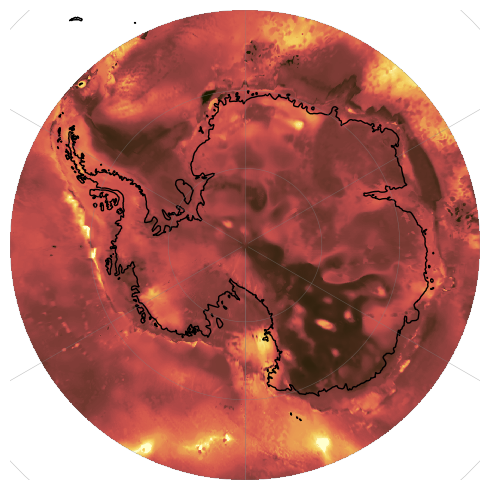

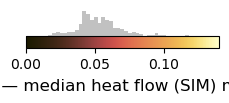

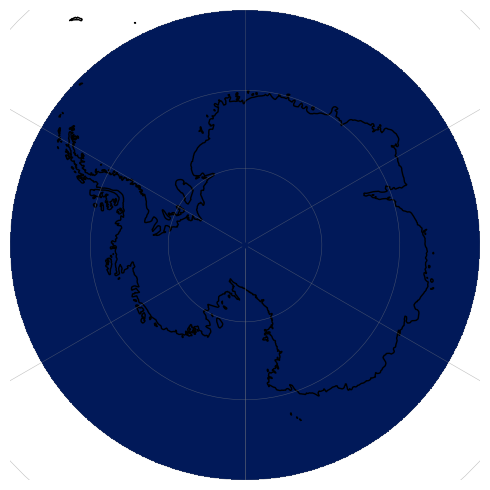

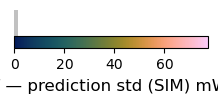

[ANT] maps done.


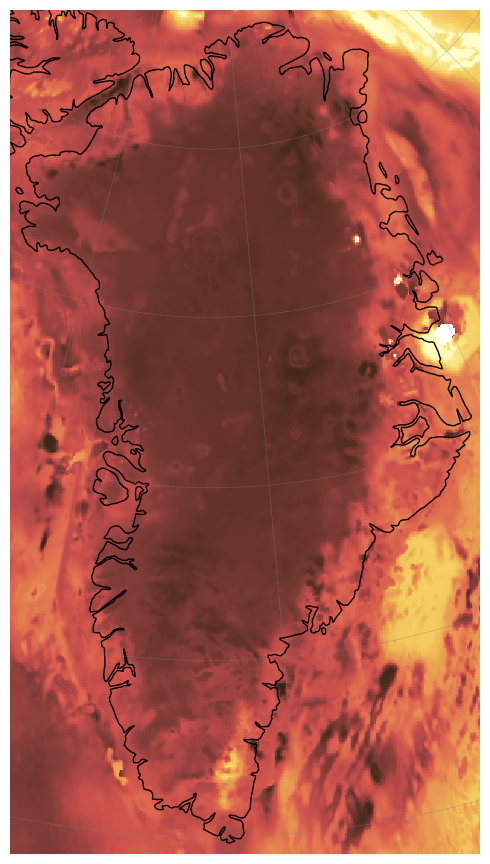

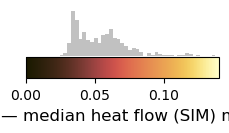

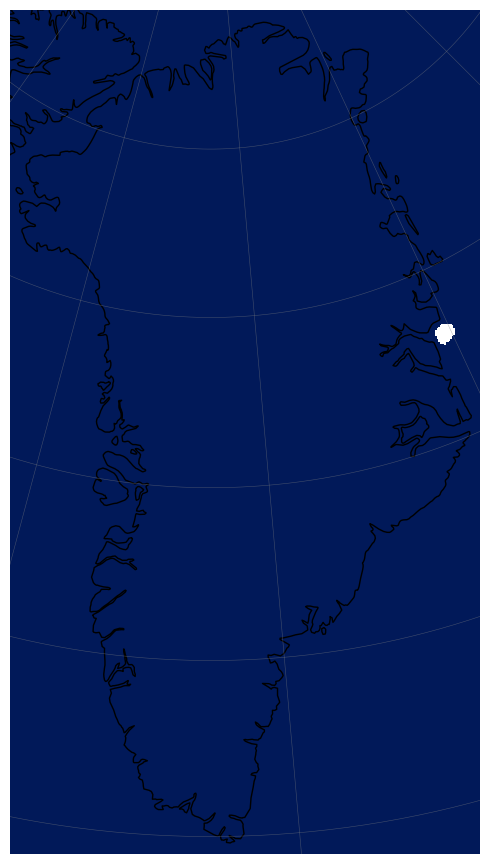

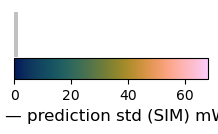

[GRL] maps done.


In [10]:
from lib.utils import grid_from_xr_dataset

# Stage-5 similarity maps through the shared helper (config cmaps).
# Median heat flow uses the heat-flow scale; the per-cell std uses the
# uncertainty scale; sim_N (neighbour count) is a diagnostic, auto-scaled.
for label, ds in results_sim_ds.items():
    g = grid_from_xr_dataset(ds, name=label)
    if 'sim_q50_corr' in ds:
        save_target_map(g, 'sim_q50_corr', cmap=hf_cmap, vmin=q_min, vmax=q_max,
                        label=label, cbar_title=f'{label.upper()} — median heat flow (SIM)',
                        units=hf_unit)
    if 'sim_std_corr' in ds:
        std_mW = to_mW(ds['sim_std_corr'].values)
        save_target_map(g, 'sim_std_corr', cmap=unc_cmap, vmin=0.0,
                        vmax=float(np.nanpercentile(std_mW, VAR_PCTL_CAP)),
                        label=label, cbar_title=f'{label.upper()} — prediction std (SIM)',
                        units=unc_unit)
    print(f'[{label.upper()}] maps done.')


## 7. Histogram spot-check

Plot per-point histograms for a random sample of target points to verify the output PDF shapes.

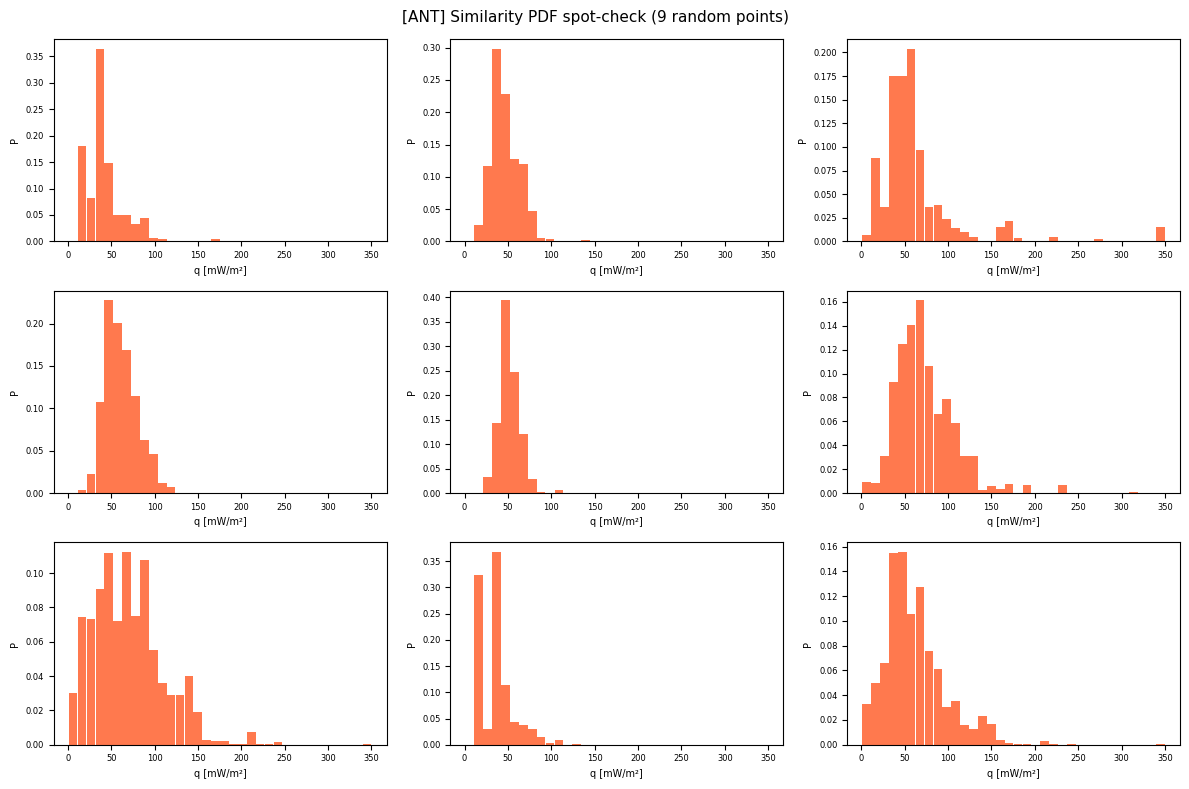

[ANT] histogram spot-check done.


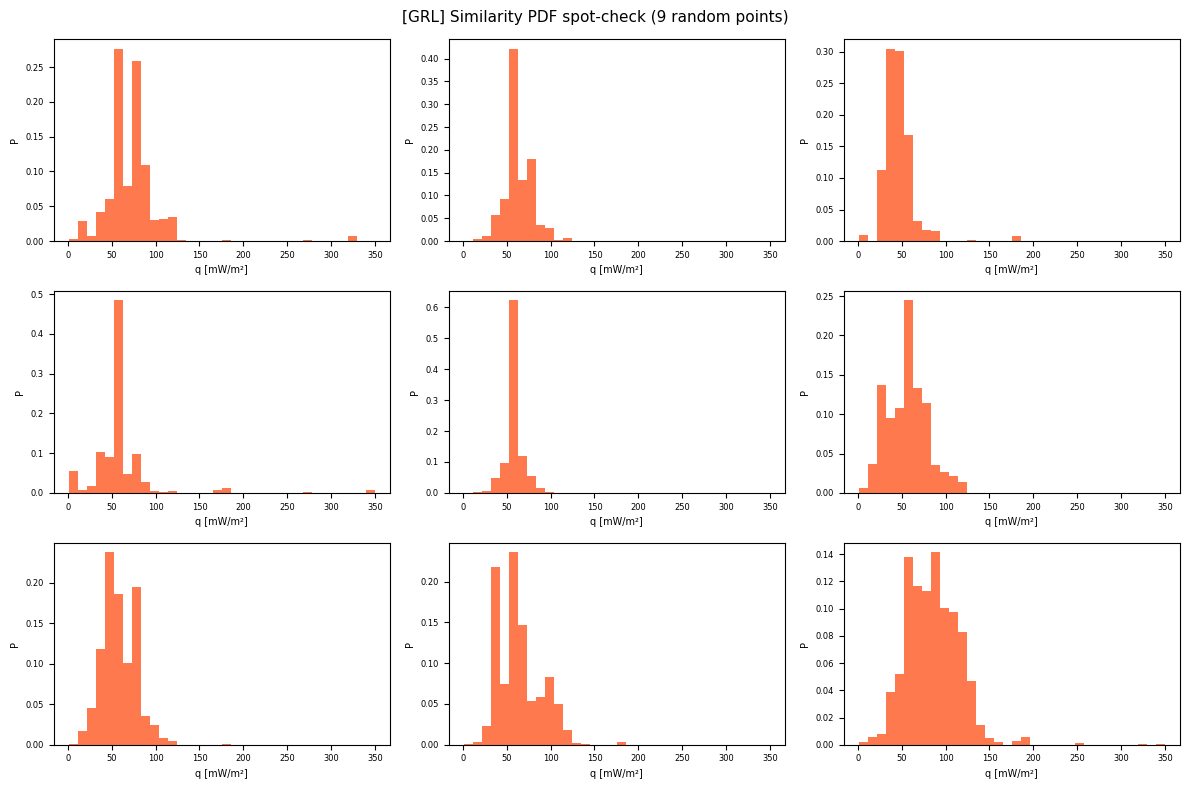

[GRL] histogram spot-check done.


In [11]:


rng = np.random.default_rng(42)

for label, ds in results_sim_ds.items():
    if 'sim_hist' not in ds:
        continue
    hist_arr = ds['sim_hist'].values          # (ny, nx, n_bins)
    ny, nx, nb = hist_arr.shape
    flat_hist = hist_arr.reshape(-1, nb)

    # pick 9 random finite-histogram points
    row_sums  = flat_hist.sum(axis=1)
    valid_idx = np.where(row_sums > 0)[0]
    n_show    = min(9, len(valid_idx))
    sample    = rng.choice(valid_idx, n_show, replace=False)

    fig, axes = plt.subplots(3, 3, figsize=(12, 8))
    for ax, idx in zip(axes.ravel(), sample):
        ax.bar(bin_centres * 1e3, flat_hist[idx] * HIST_BIN_WIDTH,
               width=HIST_BIN_WIDTH * 1e3, color='#FF5722', alpha=0.8)
        ax.set_xlabel('q [mW/m²]', fontsize=7)
        ax.set_ylabel('P', fontsize=7)
        ax.tick_params(labelsize=6)
    fig.suptitle(f'[{label.upper()}] Similarity PDF spot-check (9 random points)',
                 fontsize=11)
    fig.tight_layout()
    plt.show()
    print(f'[{label.upper()}] histogram spot-check done.')

In [12]:
import pandas as pd
df_ant = pd.read_parquet(parquet_ant, columns=['REVEAL_P150'])
print(f"REVEAL_P150 NaN fraction: {df_ant['REVEAL_P150'].isna().mean():.3f}")
print(f"REVEAL_P150 range: [{df_ant['REVEAL_P150'].min():.3f}, {df_ant['REVEAL_P150'].max():.3f}]")

REVEAL_P150 NaN fraction: 0.000
REVEAL_P150 range: [7.860, 8.389]


In [13]:
for grid_cfg in TARGET_GRIDS:
    lbl = grid_cfg['label']
    df_g = pd.read_parquet(grid_cfg['parquet'])
    nan_counts = {f: int(df_g[f].isna().sum()) for f in obs_sel if df_g[f].isna().any()}
    print(f"[{lbl.upper()}] NaN-causing features: {nan_counts}")

[ANT] NaN-causing features: {'DEM': 383490}
[GRL] NaN-causing features: {}


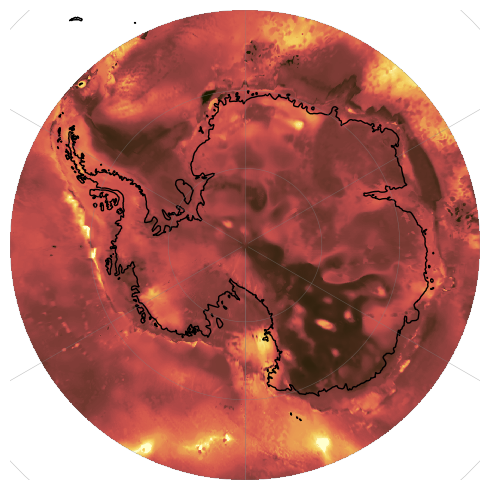

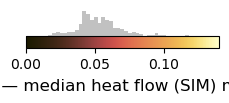

(<Figure size 500x500 with 1 Axes>, <GeoAxes: >)

In [14]:
results_sim['ant']['ds']

# Antarctica median heat flow (SIM)
save_target_map(TARGET_GRIDS[0]['agrid'], 'sim_q50_corr',
                cmap=hf_cmap, vmin=q_min, vmax=q_max, label='ant',
                cbar_title='ANT — median heat flow (SIM)', units=hf_unit,
                stem='ant_sim_q50_corr_main')


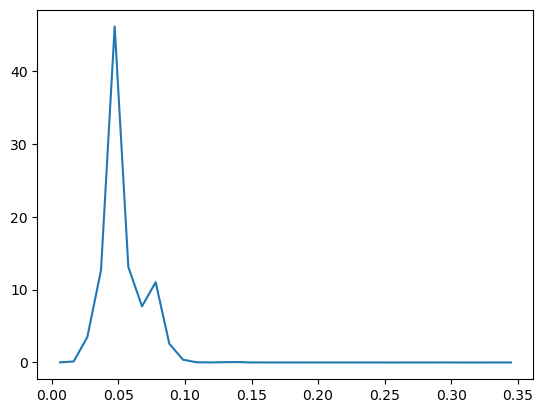

In [15]:
plt.plot(results_sim['ant']['ds']['bin'], results_sim['ant']['ds']['sim_hist'].values[400, 500, :])

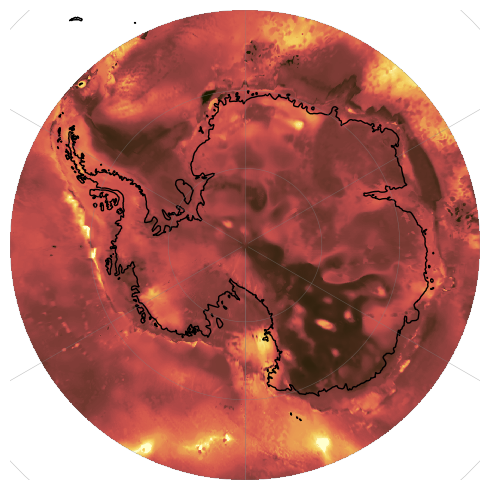

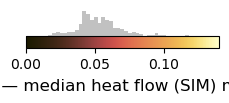

(<Figure size 500x500 with 1 Axes>, <GeoAxes: >)

In [16]:
# Antarctica median heat flow (SIM) — repeat view
save_target_map(TARGET_GRIDS[0]['agrid'], 'sim_q50_corr',
                cmap=hf_cmap, vmin=q_min, vmax=q_max, label='ant',
                cbar_title='ANT — median heat flow (SIM)', units=hf_unit,
                stem='ant_sim_q50_corr_view2')
